In [1]:
%pip install tensorflow numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Handwritten Arabic Digit Recognition

This project builds a computer vision model to recognize handwritten digits (0–9) using a Convolutional Neural Network (CNN).

## Import Libraries

In this step, I import the necessary Python libraries required for data processing, visualization, and building the deep learning model.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("Libraries loaded successfully")


Libraries loaded successfully


## Dataset Loading

Load the MNIST handwritten digit dataset which contains images of digits from 0 to 9. Each image has a resolution of 28×28 pixels.

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training samples:", x_train.shape)
print("Testing samples:", x_test.shape)

Training samples: (60000, 28, 28)
Testing samples: (10000, 28, 28)


## Data Visualization

Visualize some sample images from the dataset to understand how the handwritten digits look and verify the labels.

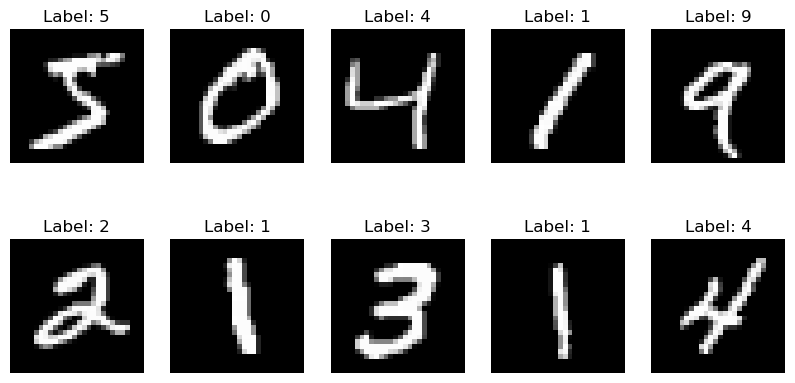

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.show()

## Data Preprocessing

Before training the model, I normalize the pixel values to the range [0,1] and reshape the images to include a channel dimension required for CNN models.

In [5]:
# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Max value:", x_train.max())
print("Min value:", x_train.min())

Max value: 1.0
Min value: 0.0


In [6]:
# Reshape data for CNN
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print("New shape:", x_train.shape)

New shape: (60000, 28, 28, 1)


## CNN Model Architecture

Build a Convolutional Neural Network (CNN) to automatically extract features from the images and classify them into one of the 10 digit classes.

In [7]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

d:\conda_envs\ml_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Model Training

The model is trained using the Adam optimizer and sparse categorical crossentropy loss function for multiple epochs.

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9579 - loss: 0.1378 - val_accuracy: 0.9855 - val_loss: 0.0469
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9859 - loss: 0.0451 - val_accuracy: 0.9878 - val_loss: 0.0387
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9901 - loss: 0.0320 - val_accuracy: 0.9885 - val_loss: 0.0367
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9922 - loss: 0.0245 - val_accuracy: 0.9889 - val_loss: 0.0316
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9943 - loss: 0.0176 - val_accuracy: 0.9910 - val_loss: 0.0297
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9955 - loss: 0.0145 - val_accuracy: 0.9910 - val_loss: 0.0330
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9966 - loss: 0.0109 - val_accuracy: 0.9902 - val_loss: 0.0404
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9968 - 

## Model Evaluation

After training, evaluate the model using the test dataset to measure its performance and classification accuracy.

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9893 - loss: 0.0458
Test Accuracy: 0.989300012588501


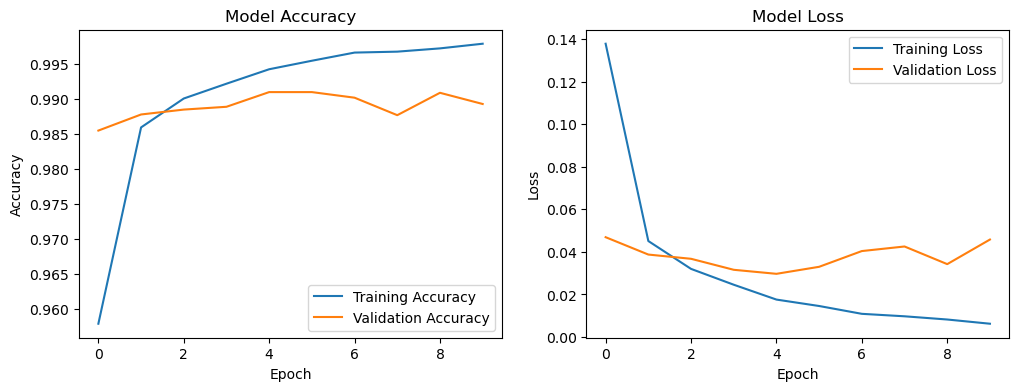

In [13]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Predictions

Finally, use the trained model to predict digits from the test dataset and visualize the predicted results.

In [14]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


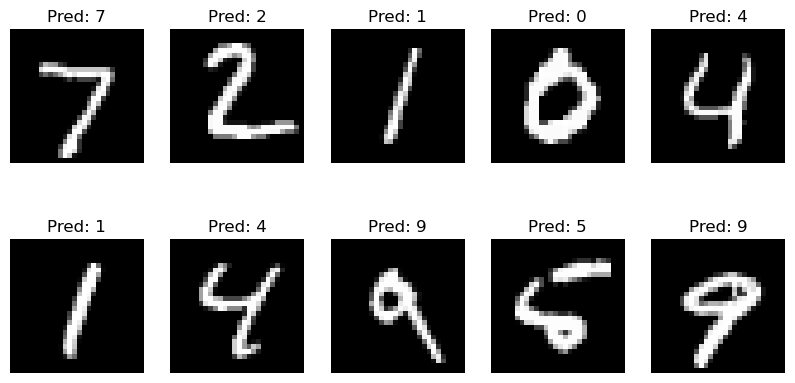

In [15]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Pred: " + str(np.argmax(predictions[i])))
    plt.axis('off')

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


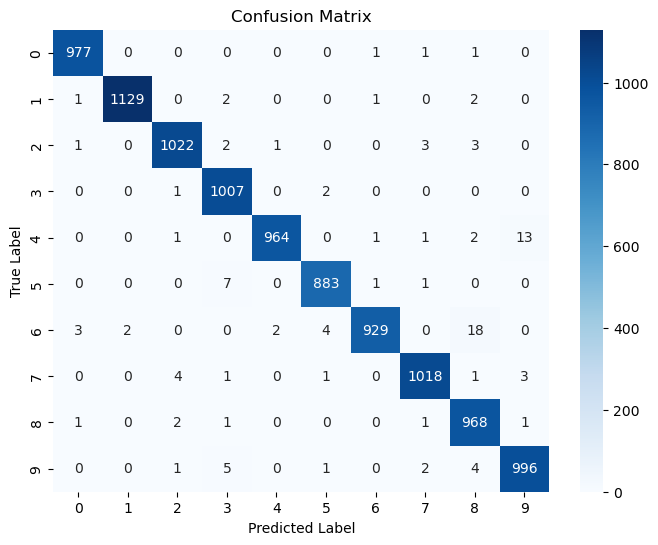

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Conclusion

In this project, a Convolutional Neural Network (CNN) was developed to recognize handwritten digits using the MNIST dataset. 

The model achieved high accuracy (approximately 99%) on the test dataset, demonstrating the effectiveness of deep learning techniques in image classification tasks.

Future improvements could include using deeper CNN architectures or applying data augmentation to further improve generalization.